# My LoRA Variant
LoRA+ introduced dynamic learning rates for A and B matrices. Could we achieve the same thing if we added a penalty to the loss function that grows large if the difference between the magnitudes of the parameters of A and B are big?

The following experiments will test if this idea is even worth exploring.

For loading SST-2 and preprocessing dataset, run the cell below.

In [3]:
from transformers import AutoTokenizer
from torch.utils.data import DataLoader
from datasets import load_dataset

# SST-2 from the GLUE benchmark
dataset = load_dataset('glue', 'sst2')

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

def tokenize(example):
    return tokenizer(example['sentence'], truncation=True, padding='max_length', max_length=128)

tokenized = dataset.map(tokenize, batched=True)
tokenized.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

Map: 100%|██████████| 872/872 [00:00<00:00, 10072.27 examples/s]


For loading QQP and preprocessing dataset, run the cell below.

In [4]:
from transformers import AutoTokenizer
from torch.utils.data import DataLoader
from datasets import load_dataset

# QQP from the GLUE benchmark
dataset = load_dataset("glue", "qqp")

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def tokenize(example):
    return tokenizer(example['question1'], example['question2'],
                     truncation=True, padding='max_length', max_length=128)

tokenized = dataset.map(tokenize, batched=True)
tokenized = tokenized.rename_column("label", "labels")  
tokenized.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

Map: 100%|██████████| 390965/390965 [00:41<00:00, 9375.97 examples/s] 


**Note**: Remember to reset the model before every experiment. To do so, rerun the cell below.

In [5]:
from transformers import AutoModelForSequenceClassification
from peft import get_peft_model, LoraConfig, TaskType

# *Note* : Binary classification can be done with num_labels=1, but the loss must manually be calculated with torch.nn.BCEWithLogitsLoss. This is because when num_labels=1, HuggingFace
#          thinks you are doing regression, and returns MSE loss. Hence for convenience sake we will set the num_labels=2 as it is essentially the same thing for binary classification.
model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=2) # if num labels is set to one, the loss will be MSE apparently

lora_config = LoraConfig(
    r=8,
    lora_alpha=8,
    target_modules=['query', 'value'],  # ['key', 'query', 'value', 'dense']
    lora_dropout=0.1,
    bias='none',
    task_type=TaskType.SEQ_CLS  # Sequence classification
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers and GPU quantization are unavailable.


trainable params: 887,042 || all params: 125,534,212 || trainable%: 0.7066


## Training with normal LoRA

In [6]:
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm import tqdm
import torch

BATCH_SIZE = 16
LR = 2e-4
NUM_EPOCHS = 3
MAX_STEPS = 6000
DEVICE = 'cuda'
OPTIMIZER = AdamW(model.parameters(), lr=LR)
STEPS_BETWEEN_VALIDATION = 100 # to validate once after every epoch instead, set STEPS_BETWEEN_VALIDATION=None

train_loader = DataLoader(tokenized['train'], batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(tokenized['validation'], batch_size=BATCH_SIZE)

device = torch.device(DEVICE if torch.cuda.is_available() else 'cpu')
optimizer = OPTIMIZER
model.to(device)
model.train()

training_losses = []
validation_losses = []
step = 0
should_stop = False
for epoch in range(NUM_EPOCHS):

    # training loop
    train_iter = tqdm(train_loader, desc=f'Epoch {epoch+1} Training', leave=False)
    total_training_loss = 0
    for train_batch in train_iter:
        inputs = {k if k != 'label' else 'labels': v.to(device) for k, v in train_batch.items()}
        outputs = model(**inputs)
        loss = outputs.loss
        total_training_loss += loss.item()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        step += 1
        # break out of the inner loop when step has reached MAX_STEPS
        if (MAX_STEPS is not None) and (step >= MAX_STEPS):
            should_stop = True
            break
        
        # validation loop (once after every STEPS_BETWEEN_VALIDATION steps)
        if STEPS_BETWEEN_VALIDATION is not None:
            if step % STEPS_BETWEEN_VALIDATION == 0:
                val_iter = tqdm(val_loader, desc=f'step {step}: Validating', leave=False)
                model.eval()
                total_val_loss = 0
                for val_batch in val_iter:
                    inputs = {k if k != 'label' else 'labels': v.to(device) for k, v in val_batch.items()}
                    with torch.no_grad():
                        outputs = model(**inputs)
                    loss = outputs.loss
                    total_val_loss += loss.item()
                val_loss = total_val_loss / len(val_loader)
                training_loss = total_training_loss / STEPS_BETWEEN_VALIDATION
                total_val_loss = 0
                total_training_loss = 0
                print(f'step {step}: ')
                print(f'    Training Loss = {training_loss:.4f}')
                print(f'    Validation Loss = {val_loss:.4f}')
                validation_losses.append((step, val_loss))
                training_losses.append((step, training_loss))
                model.train()


    # validation loop (once after every epoch)
    if STEPS_BETWEEN_VALIDATION == None:
        val_iter = tqdm(val_loader, desc=f'Epoch {epoch+1} Validating', leave=False)
        model.eval()
        total_val_loss = 0
        for val_batch in val_iter:
            inputs = {k if k != 'label' else 'labels': v.to(device) for k, v in val_batch.items()}
            with torch.no_grad():
                outputs = model(**inputs)
            loss = outputs.loss
            total_val_loss += loss.item()
        val_loss = total_val_loss / len(val_loader)
        training_loss = total_training_loss / len(train_loader)        
        total_val_loss = 0
        total_training_loss = 0
        print(f'Epoch {epoch + 1}: ')
        print(f'    Training Loss = {training_loss:.4f}')
        print(f'    Validation Loss = {val_loss:.4f}')
        validation_losses.append((epoch, val_loss))
        training_losses.append((epoch, training_loss))
        model.train()
    
    # break out of the main loop when step has reached MAX_STEPS
    if should_stop:
        break


KeyboardInterrupt: 

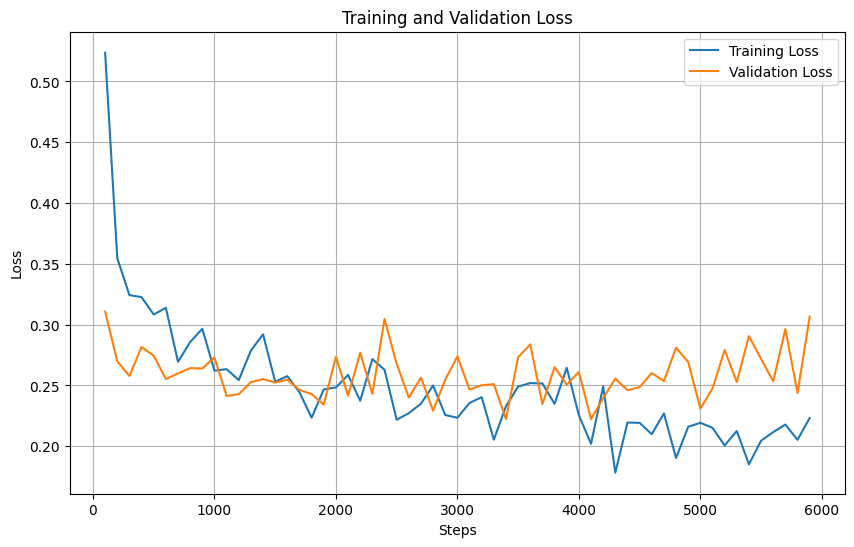

In [35]:
import matplotlib.pyplot as plt

# Separate steps and losses
train_steps, train_values = zip(*training_losses)
val_steps, val_values = zip(*validation_losses)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_values, label='Training Loss')
plt.plot(val_steps, val_values, label='Validation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


## Training with the LoRA variant
Different penalties can be added to the loss to force the $A$ and $B$ matrices of each adapter to have parameters of almost equal magnitude. Note that we will monitor only the CE loss, without the penalty, so that we can fairly compare the this LoRA variant to the vanilla LoRA.

### Penalty 1:

$$
L_{\text{penalty}} = \frac{1}{N} \sum_{i=1}^N \left( \frac{ \vert{A_i} \rVert_2 }{\sqrt{d_{\text{in},i} \cdot r_i}} - \frac{ \vert{B_i} \rVert_2 }{\sqrt{d_{\text{out},i} \cdot r_i}} \right)^2 \text{, for adapters $1, \cdots, N$.}
$$

Note that this penalty only accounts for A and B matrices within the same adapter. To keep the magnitude of the parameters of **all** LoRA adapters roughly the same, we can add L2 regularization. Optimizers like AdamW already do include this as weight decay but other optimizers may require a separate penalty for L2 regularization.

In [38]:
import math
import torch

def get_penalty_1(model):
    penalty = 0.0
    N = 0  # number of adapters

    for module in model.modules():
        if hasattr(module, 'lora_A') and hasattr(module, 'lora_B'):
            # print(module)
            A_layer = module.lora_A['default']
            B_layer = module.lora_B['default']
            A = A_layer.weight
            B = B_layer.weight

            # L2 Norm is the same as the Frobenius Norm for matrices
            A_norm = torch.norm(A, p=2)
            B_norm = torch.norm(B, p=2)

            din = A.shape[1]
            dout = B.shape[0]
            r = A.shape[0] 

            penalty += ((A_norm / math.sqrt(din * r)) - (B_norm / math.sqrt(dout * r))) ** 2
            N += 1

    return penalty / N

# get_penalty(model)

In [ ]:
from torch.utils.data import DataLoader
import torch
from torch.optim import AdamW
from tqdm import tqdm

BATCH_SIZE = 16
LR = 2e-4
NUM_EPOCHS = 3
MAX_STEPS = 6000
DEVICE = 'cuda'
OPTIMIZER = AdamW(model.parameters(), lr=LR)
STEPS_BETWEEN_VALIDATION = 100 # to validate once after every epoch instead, set STEPS_BETWEEN_VALIDATION=None
LAMBDA = 0.2 # the weight given to L_penalty

train_loader = DataLoader(tokenized['train'], batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(tokenized['validation'], batch_size=BATCH_SIZE)

device = torch.device(DEVICE if torch.cuda.is_available() else 'cpu')
optimizer = OPTIMIZER
model.to(device)
model.train()

training_losses = []
validation_losses = []
step = 0
should_stop = False
for epoch in range(NUM_EPOCHS):

    # training loop
    train_iter = tqdm(train_loader, desc=f'Epoch {epoch+1} Training', leave=False)
    total_training_loss = 0
    for train_batch in train_iter:
        inputs = {k if k != 'label' else 'labels': v.to(device) for k, v in train_batch.items()}
        outputs = model(**inputs)
        CEloss = outputs.loss
        total_training_loss += CEloss.item() # we only want to monitor the CE loss

        penalty = get_penalty_1(model)
        loss = CEloss + LAMBDA * penalty
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        step += 1
        # break out of the inner loop when step has reached MAX_STEPS
        if (MAX_STEPS is not None) and (step >= MAX_STEPS):
            should_stop = True
            break
        
        # validation loop (once after every STEPS_BETWEEN_VALIDATION steps)
        if STEPS_BETWEEN_VALIDATION is not None:
            if step % STEPS_BETWEEN_VALIDATION == 0:
                val_iter = tqdm(val_loader, desc=f'step {step}: Validating', leave=False)
                model.eval()
                total_val_loss = 0
                for val_batch in val_iter:
                    inputs = {k if k != 'label' else 'labels': v.to(device) for k, v in val_batch.items()}
                    with torch.no_grad():
                        outputs = model(**inputs)
                    loss = outputs.loss
                    total_val_loss += loss.item() # we only want to monitor the CE loss
                val_loss = total_val_loss / len(val_loader)
                training_loss = total_training_loss / STEPS_BETWEEN_VALIDATION
                total_val_loss = 0
                total_training_loss = 0
                print(f'step {step}: ')
                print(f'    Training Loss = {training_loss:.4f}')
                print(f'    Validation Loss = {val_loss:.4f}')
                validation_losses.append((step, val_loss))
                training_losses.append((step, training_loss))
                model.train()


    # validation loop (once after every epoch)
    if STEPS_BETWEEN_VALIDATION == None:
        val_iter = tqdm(val_loader, desc=f'Epoch {epoch+1} Validating', leave=False)
        model.eval()
        total_val_loss = 0
        for val_batch in val_iter:
            inputs = {k if k != 'label' else 'labels': v.to(device) for k, v in val_batch.items()}
            with torch.no_grad():
                outputs = model(**inputs)

            loss = outputs.loss # we only want to monitor the CE loss
            total_val_loss += loss.item()
        val_loss = total_val_loss / len(val_loader)
        training_loss = total_training_loss / len(train_loader)        
        total_val_loss = 0
        total_training_loss = 0
        print(f'Epoch {epoch + 1}: ')
        print(f'    Training Loss = {training_loss:.4f}')
        print(f'    Validation Loss = {val_loss:.4f}')
        validation_losses.append((epoch, val_loss))
        training_losses.append((epoch, training_loss))
        model.train()
    
    # break out of the main loop when step has reached MAX_STEPS
    if should_stop:
        break

Epoch 1 Training:   2%|▏         | 101/4210 [00:25<1:25:54,  1.25s/it]

step 100: 
    Training Loss = 0.5331
    Validation Loss = 0.3313


Epoch 1 Training:   5%|▍         | 201/4210 [00:51<1:26:05,  1.29s/it]

step 200: 
    Training Loss = 0.3819
    Validation Loss = 0.2902


Epoch 1 Training:   7%|▋         | 301/4210 [01:18<1:30:40,  1.39s/it]

...

step 5700: 
    Training Loss = 0.1949
    Validation Loss = 0.2606


Epoch 2 Training:  38%|███▊      | 1591/4210 [07:15<1:06:42,  1.53s/it]

step 5800: 
    Training Loss = 0.1876
    Validation Loss = 0.3663


Epoch 2 Training:  40%|████      | 1691/4210 [07:46<1:05:22,  1.56s/it]

step 5900: 
    Training Loss = 0.2071
    Validation Loss = 0.2779


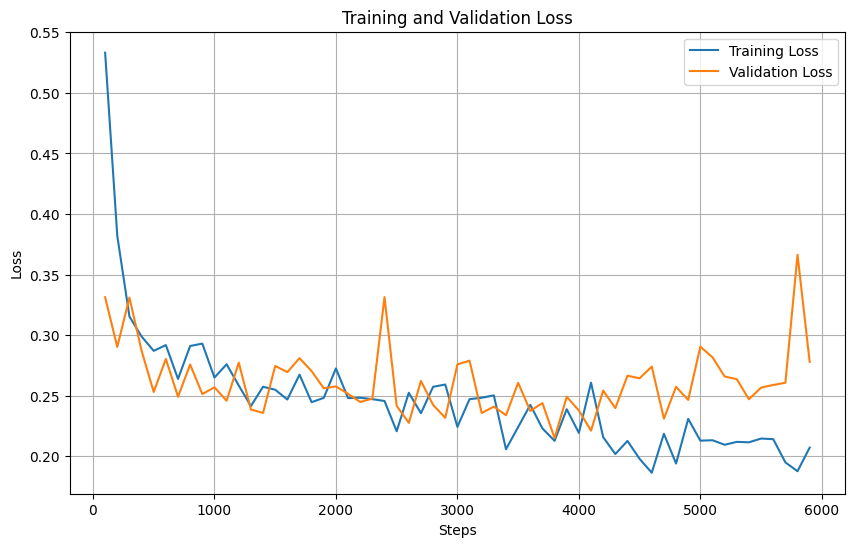

In [40]:
import matplotlib.pyplot as plt

# Separate steps and losses
train_steps, train_values = zip(*training_losses)
val_steps, val_values = zip(*validation_losses)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_values, label='Training Loss')
plt.plot(val_steps, val_values, label='Validation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


### Penalty 2:

Since our goal is to reduce the difference in the **order of magnitude** between the parameters of the 2 matrices, it would seem more appropriate to get

$\frac{\lVert{A} \rVert_2 / \sqrt{r \cdot d_{\text{in}}}}{\lVert{B} \rVert_2 / \sqrt{r \cdot d_{\text{out}}}}$ as close to 1 as possible. Hence we try:

$$
L_{\text{penalty}} = \frac{1}{N} \sum_{i=1}^N \left( \log\left( \frac{ \lVert{ A \rVert_2 } }{ \sqrt{r \cdot d_{\text{in}}} } + \varepsilon \right) - \log\left( \frac{ \lVert{ B \rVert_2 }}{ \sqrt{r \cdot d_{\text{out}}} } + \varepsilon \right ) \right)^2, \quad \text{where } \varepsilon = 10^{-8}
$$



In [26]:
import math
import torch

def get_penalty_2(model, epsilon=1e-8):
    penalty = 0.0
    N = 0  # number of adapters

    for module in model.modules():
        if hasattr(module, 'lora_A') and hasattr(module, 'lora_B'):
            # print(module)
            A_layer = module.lora_A['default']
            B_layer = module.lora_B['default']
            A = A_layer.weight
            B = B_layer.weight

            # L2 Norm is the same as the Frobenius Norm for matrices
            A_norm = torch.norm(A, p=2)
            B_norm = torch.norm(B, p=2)

            din = A.shape[1]
            dout = B.shape[0]
            r = A.shape[0] 

            penalty += (torch.log((A_norm / math.sqrt(din * r)) + epsilon) - torch.log((B_norm / math.sqrt(dout * r)) + epsilon)) ** 2
            N += 1

    return penalty / N

In [ ]:
from torch.utils.data import DataLoader
import torch
from torch.optim import AdamW
from tqdm import tqdm

BATCH_SIZE = 16
LR = 2e-4
NUM_EPOCHS = 3
MAX_STEPS = 6000
DEVICE = 'cuda'
OPTIMIZER = AdamW(model.parameters(), lr=LR)
STEPS_BETWEEN_VALIDATION = 100 # to validate once after every epoch instead, set STEPS_BETWEEN_VALIDATION=None
LAMBDA = 0.2 # the weight given to L_penalty

train_loader = DataLoader(tokenized['train'], batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(tokenized['validation'], batch_size=BATCH_SIZE)

device = torch.device(DEVICE if torch.cuda.is_available() else 'cpu')
optimizer = OPTIMIZER
model.to(device)
model.train()

training_losses = []
validation_losses = []
step = 0
should_stop = False
for epoch in range(NUM_EPOCHS):

    # training loop
    train_iter = tqdm(train_loader, desc=f'Epoch {epoch+1} Training', leave=False)
    total_training_loss = 0
    for train_batch in train_iter:
        inputs = {k if k != 'label' else 'labels': v.to(device) for k, v in train_batch.items()}
        outputs = model(**inputs)
        CEloss = outputs.loss
        total_training_loss += CEloss.item() # we only want to monitor the CE loss

        penalty = get_penalty_2(model)
        loss = CEloss + LAMBDA * penalty
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        step += 1
        # break out of the inner loop when step has reached MAX_STEPS
        if (MAX_STEPS is not None) and (step >= MAX_STEPS):
            should_stop = True
            break
        
        # validation loop (once after every STEPS_BETWEEN_VALIDATION steps)
        if STEPS_BETWEEN_VALIDATION is not None:
            if step % STEPS_BETWEEN_VALIDATION == 0:
                val_iter = tqdm(val_loader, desc=f'step {step}: Validating', leave=False)
                model.eval()
                total_val_loss = 0
                for val_batch in val_iter:
                    inputs = {k if k != 'label' else 'labels': v.to(device) for k, v in val_batch.items()}
                    with torch.no_grad():
                        outputs = model(**inputs)
                    loss = outputs.loss
                    total_val_loss += loss.item() # we only want to monitor the CE loss
                val_loss = total_val_loss / len(val_loader)
                training_loss = total_training_loss / STEPS_BETWEEN_VALIDATION
                total_val_loss = 0
                total_training_loss = 0
                print(f'step {step}: ')
                print(f'    Training Loss = {training_loss:.4f}')
                print(f'    Validation Loss = {val_loss:.4f}')
                validation_losses.append((step, val_loss))
                training_losses.append((step, training_loss))
                model.train()


    # validation loop (once after every epoch)
    if STEPS_BETWEEN_VALIDATION == None:
        val_iter = tqdm(val_loader, desc=f'Epoch {epoch+1} Validating', leave=False)
        model.eval()
        total_val_loss = 0
        for val_batch in val_iter:
            inputs = {k if k != 'label' else 'labels': v.to(device) for k, v in val_batch.items()}
            with torch.no_grad():
                outputs = model(**inputs)

            loss = outputs.loss # we only want to monitor the CE loss
            total_val_loss += loss.item()
        val_loss = total_val_loss / len(val_loader)
        training_loss = total_training_loss / len(train_loader)        
        total_val_loss = 0
        total_training_loss = 0
        print(f'Epoch {epoch + 1}: ')
        print(f'    Training Loss = {training_loss:.4f}')
        print(f'    Validation Loss = {val_loss:.4f}')
        validation_losses.append((epoch, val_loss))
        training_losses.append((epoch, training_loss))
        model.train()
    
    # break out of the main loop when step has reached MAX_STEPS
    if should_stop:
        break

Epoch 1 Training:   2%|▏         | 101/4210 [00:24<1:21:54,  1.20s/it]

step 100: 
    Training Loss = 0.6830
    Validation Loss = 0.6751


Epoch 1 Training:   5%|▍         | 201/4210 [00:49<1:23:04,  1.24s/it]

step 200: 
    Training Loss = 0.6413
    Validation Loss = 0.4987


Epoch 1 Training:   7%|▋         | 301/4210 [01:14<1:20:45,  1.24s/it]

...

step 5700: 
    Training Loss = 0.1961
    Validation Loss = 0.2225


Epoch 2 Training:  38%|███▊      | 1591/4210 [06:28<52:37,  1.21s/it]  

step 5800: 
    Training Loss = 0.1983
    Validation Loss = 0.2255


Epoch 2 Training:  40%|████      | 1691/4210 [06:53<50:37,  1.21s/it]  

step 5900: 
    Training Loss = 0.2085
    Validation Loss = 0.2159


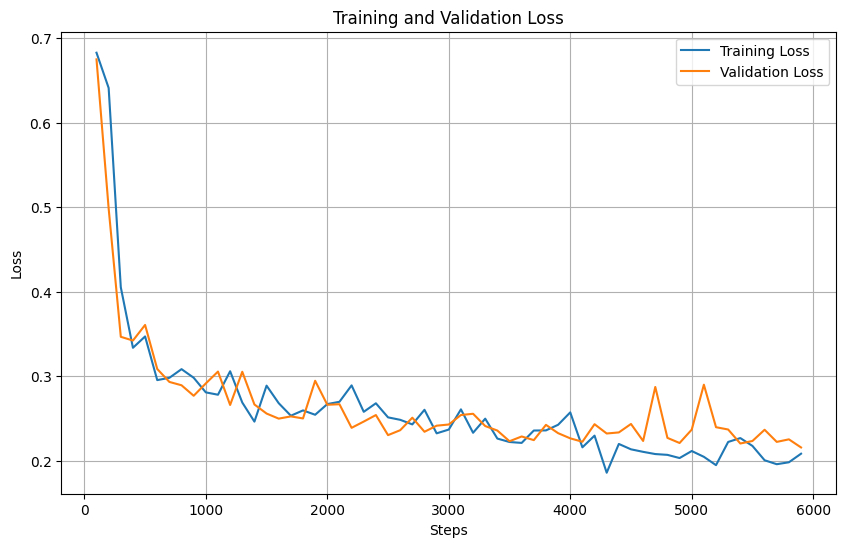

In [28]:
import matplotlib.pyplot as plt

# Separate steps and losses
train_steps, train_values = zip(*training_losses)
val_steps, val_values = zip(*validation_losses)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_values, label='Training Loss')
plt.plot(val_steps, val_values, label='Validation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()